## Customer Segmentation and Churn Prediction using Machine Learning



In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Dataset

In [39]:
df = pd.read_excel("Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Dataset Information

In [40]:
print("Rows and Columns :", df.shape)

Rows and Columns : (7043, 33)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [42]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [43]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


# Data Cleaning

In [44]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

print("Missing values removed successfully.")

Missing values removed successfully.


# Exploratory Data Analysis

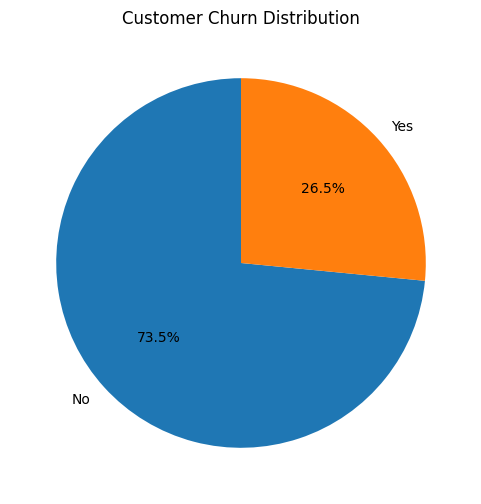

In [45]:
plt.figure(figsize=(6,6))

plt.pie(
    df['Churn Label'].value_counts(),
    labels=df['Churn Label'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Churn Distribution")

plt.show()

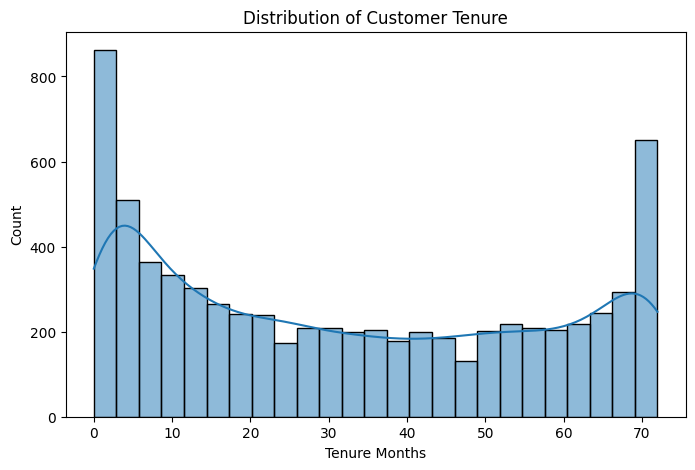

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Tenure Months'],
    bins=25,
    kde=True
)

plt.title("Distribution of Customer Tenure")

plt.xlabel("Tenure Months")

plt.show()

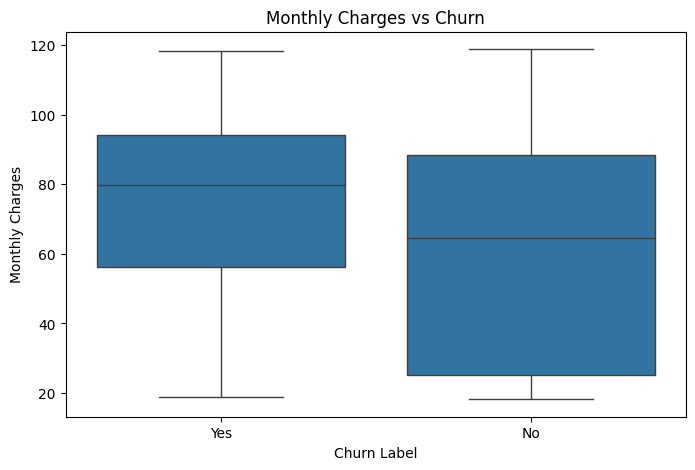

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

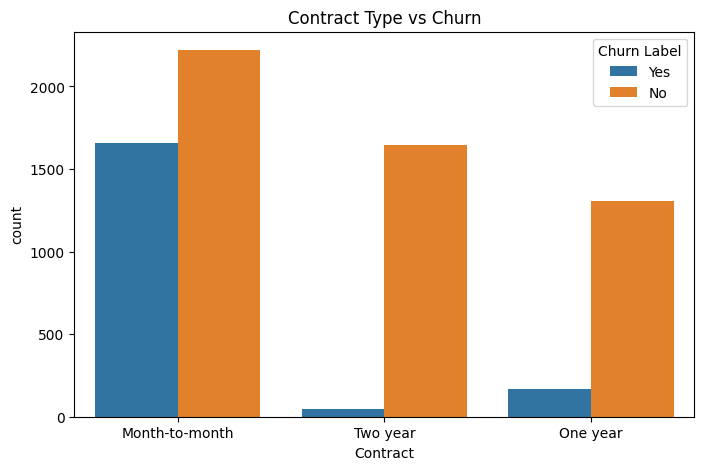

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

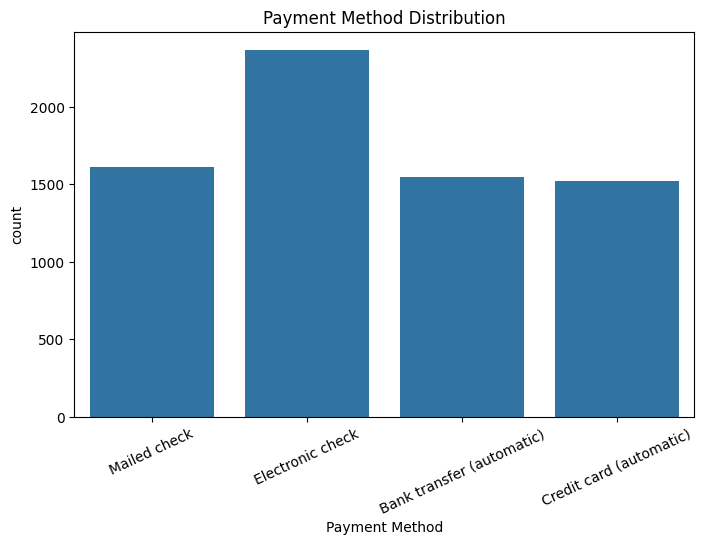

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Payment Method',
    data=df
)

plt.xticks(rotation=25)

plt.title("Payment Method Distribution")

plt.show()

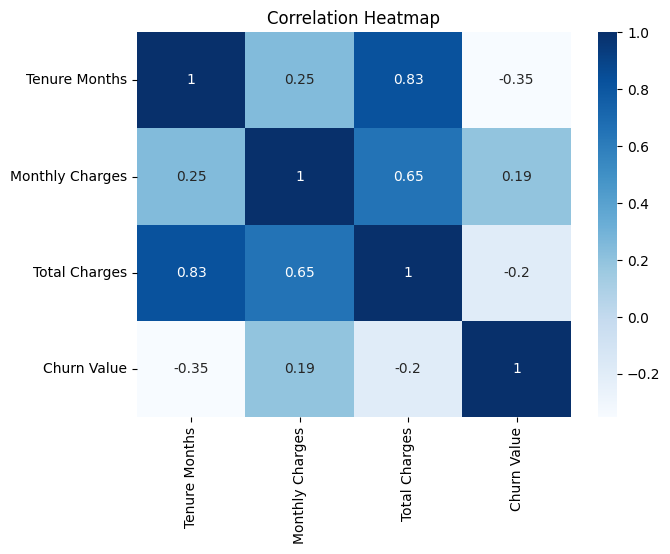

In [50]:
numeric_columns = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Value'
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# Customer Segmentation using K-Means Clustering



In [51]:
segment_data = df[
    [
        'Tenure Months',
        'Monthly Charges',
        'Total Charges'
    ]
]

segment_data.head()

,Tenure Months,Monthly Charges,Total Charges
0,2,53.85,108.15
1,2,70.70,151.65
2,8,99.65,820.50
3,28,104.80,3046.05
4,49,103.70,5036.30


In [52]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(segment_data)

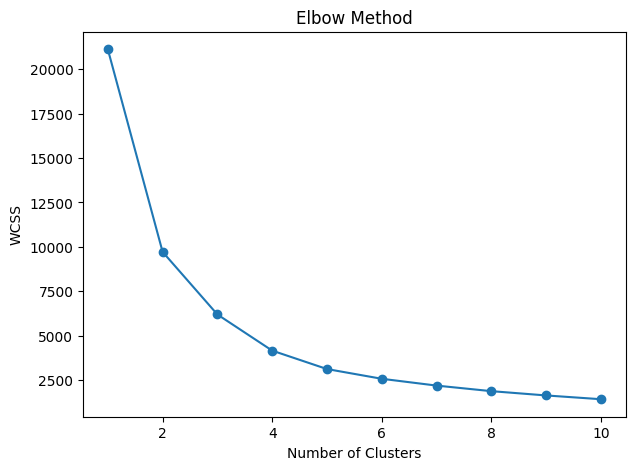

In [53]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [54]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Customer Segment'] = kmeans.fit_predict(
    scaled_data
)

In [55]:
df[['Customer Segment']].head()

,Customer Segment
0,3
1,0
2,0
3,0
4,1


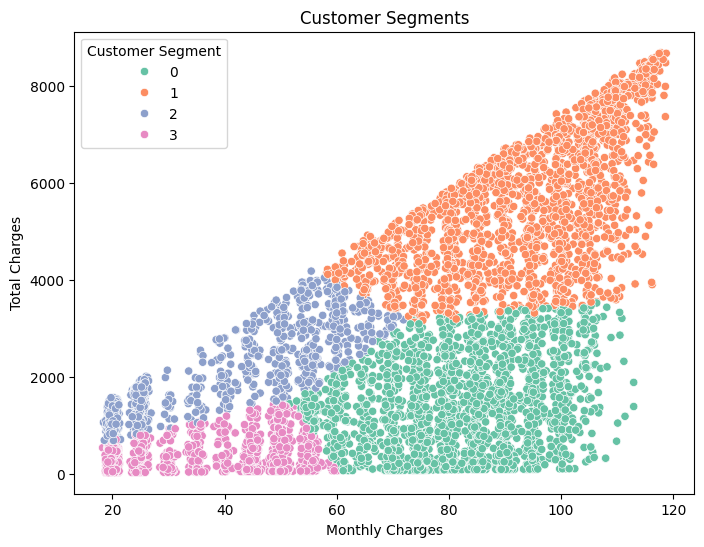

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Monthly Charges',
    y='Total Charges',
    hue='Customer Segment',
    data=df,
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

In [57]:
segment_summary = df.groupby(
    'Customer Segment'
)[
    [
        'Tenure Months',
        'Monthly Charges',
        'Total Charges'
    ]
].mean()

segment_summary

,Tenure Months,Monthly Charges,Total Charges
Customer Segment,,,
0,15.424868,80.779657,1253.007239
1,59.530987,93.306224,5548.653887
2,53.585850,34.920147,1836.581320
3,10.228873,31.769131,308.956397


In [58]:
segment_names = {
    0: "Premium Customers",
    1: "Regular Customers",
    2: "Loyal Customers",
    3: "New Customers"
}

df['Segment Name'] = df[
    'Customer Segment'
].map(segment_names)

In [59]:
df[
    [
        'Customer Segment',
        'Segment Name'
    ]
].head()

,Customer Segment,Segment Name
0,3,New Customers
1,0,Premium Customers
2,0,Premium Customers
3,0,Premium Customers
4,1,Regular Customers


# Customer Churn Prediction

In [60]:
drop_columns = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason',
    'Customer Segment',
    'Segment Name'
]

customer_df = df.drop(
    columns=drop_columns,
    errors='ignore'
)

customer_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [61]:
customer_df['Total Charges'] = pd.to_numeric(
    customer_df['Total Charges'],
    errors='coerce'
)

customer_df['Total Charges'] = customer_df[
    'Total Charges'
].fillna(
    customer_df['Total Charges'].median()
)

In [62]:
encoded_df = pd.get_dummies(
    customer_df,
    drop_first=True
)

encoded_df.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [63]:
X = encoded_df.drop(
    'Churn Value',
    axis=1
)

y = encoded_df['Churn Value']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [66]:
predictions = rf_model.predict(
    X_test
)

# Model Evaluation

In [67]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Model Accuracy :",
    round(accuracy*100,2),
    "%"
)

Model Accuracy : 79.21 %


In [68]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.68      0.52      0.58       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



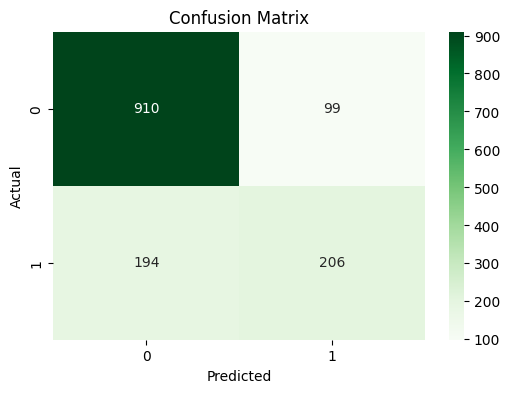

In [69]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Feature Importance

In [70]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)


,Feature,Importance
2,Total Charges,0.190676
0,Tenure Months,0.172489
1,Monthly Charges,0.167198
28,Payment Method_Electronic check,0.039318
6,Dependents_Yes,0.035169
10,Internet Service_Fiber optic,0.034031
25,Contract_Two year,0.030297
3,Gender_Male,0.027246
5,Partner_Yes,0.026040
26,Paperless Billing_Yes,0.025584


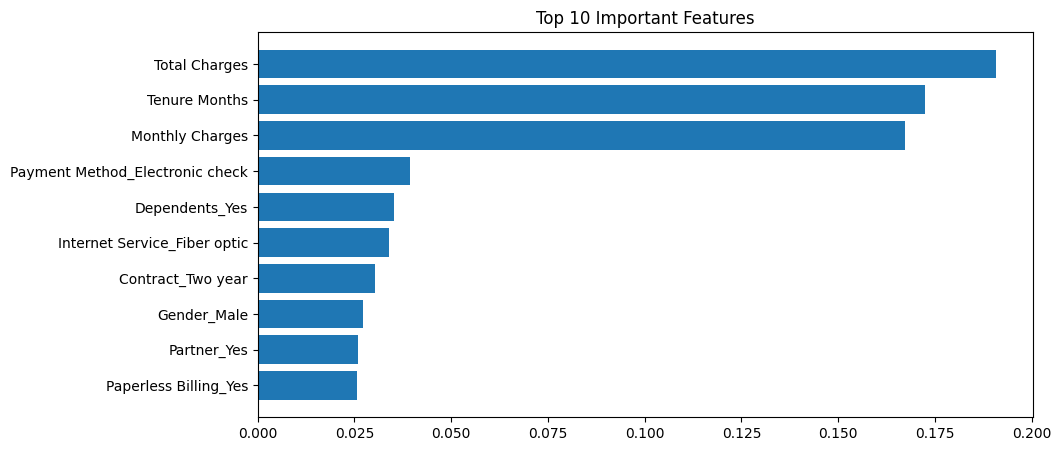

In [71]:
plt.figure(figsize=(10,5))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()